In [13]:
import os
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("EDA environment ready!")

Pandas: 3.0.5
NumPy: 2.5.2
EDA environment ready!


In [14]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

TRANSACTION_PATH = RAW_DIR / "train_transaction.csv"
IDENTITY_PATH = RAW_DIR / "train_identity.csv"

print("Transaction file:")
print(TRANSACTION_PATH)

print("\nIdentity file:")
print(IDENTITY_PATH)

print("\nTransaction exists:", TRANSACTION_PATH.exists())
print("Identity exists:", IDENTITY_PATH.exists())

Transaction file:
D:\PayGuard-AI\data\raw\train_transaction.csv

Identity file:
D:\PayGuard-AI\data\raw\train_identity.csv

Transaction exists: True
Identity exists: True


In [15]:
def file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)

print(
    f"train_transaction.csv: "
    f"{file_size_mb(TRANSACTION_PATH):.2f} MB"
)

print(
    f"train_identity.csv: "
    f"{file_size_mb(IDENTITY_PATH):.2f} MB"
)

train_transaction.csv: 651.69 MB
train_identity.csv: 25.30 MB


In [16]:
def file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)

print(
    f"train_transaction.csv: "
    f"{file_size_mb(TRANSACTION_PATH):.2f} MB"
)

print(
    f"train_identity.csv: "
    f"{file_size_mb(IDENTITY_PATH):.2f} MB"
)

train_transaction.csv: 651.69 MB
train_identity.csv: 25.30 MB


In [17]:
SAMPLE_ROWS = 10000

transaction_sample = pd.read_csv(
    TRANSACTION_PATH,
    nrows=SAMPLE_ROWS
)

identity_sample = pd.read_csv(
    IDENTITY_PATH,
    nrows=SAMPLE_ROWS
)

print("Transaction sample:", transaction_sample.shape)
print("Identity sample:", identity_sample.shape)

Transaction sample: (10000, 394)
Identity sample: (10000, 41)


In [18]:
transaction_sample.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
identity_sample.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [20]:
print("Number of transaction columns:")
print(len(transaction_sample.columns))

print("\nTransaction columns:")
for i, col in enumerate(transaction_sample.columns, start=1):
    print(f"{i:03d}. {col}")

Number of transaction columns:
394

Transaction columns:
001. TransactionID
002. isFraud
003. TransactionDT
004. TransactionAmt
005. ProductCD
006. card1
007. card2
008. card3
009. card4
010. card5
011. card6
012. addr1
013. addr2
014. dist1
015. dist2
016. P_emaildomain
017. R_emaildomain
018. C1
019. C2
020. C3
021. C4
022. C5
023. C6
024. C7
025. C8
026. C9
027. C10
028. C11
029. C12
030. C13
031. C14
032. D1
033. D2
034. D3
035. D4
036. D5
037. D6
038. D7
039. D8
040. D9
041. D10
042. D11
043. D12
044. D13
045. D14
046. D15
047. M1
048. M2
049. M3
050. M4
051. M5
052. M6
053. M7
054. M8
055. M9
056. V1
057. V2
058. V3
059. V4
060. V5
061. V6
062. V7
063. V8
064. V9
065. V10
066. V11
067. V12
068. V13
069. V14
070. V15
071. V16
072. V17
073. V18
074. V19
075. V20
076. V21
077. V22
078. V23
079. V24
080. V25
081. V26
082. V27
083. V28
084. V29
085. V30
086. V31
087. V32
088. V33
089. V34
090. V35
091. V36
092. V37
093. V38
094. V39
095. V40
096. V41
097. V42
098. V43
099. V44
100. V4

In [21]:
print("Number of identity columns:")
print(len(identity_sample.columns))

print("\nIdentity columns:")
for i, col in enumerate(identity_sample.columns, start=1):
    print(f"{i:03d}. {col}")

Number of identity columns:
41

Identity columns:
001. TransactionID
002. id_01
003. id_02
004. id_03
005. id_04
006. id_05
007. id_06
008. id_07
009. id_08
010. id_09
011. id_10
012. id_11
013. id_12
014. id_13
015. id_14
016. id_15
017. id_16
018. id_17
019. id_18
020. id_19
021. id_20
022. id_21
023. id_22
024. id_23
025. id_24
026. id_25
027. id_26
028. id_27
029. id_28
030. id_29
031. id_30
032. id_31
033. id_32
034. id_33
035. id_34
036. id_35
037. id_36
038. id_37
039. id_38
040. DeviceType
041. DeviceInfo


In [22]:
transaction_sample.dtypes.value_counts()

float64    376
str         14
int64        4
Name: count, dtype: int64

In [23]:
fraud_counts = transaction_sample["isFraud"].value_counts()

print("Fraud counts:")
print(fraud_counts)

print("\nFraud percentages:")
print(
    transaction_sample["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

Fraud counts:
isFraud
0    9735
1     265
Name: count, dtype: int64

Fraud percentages:
isFraud
0    97.35
1     2.65
Name: proportion, dtype: float64


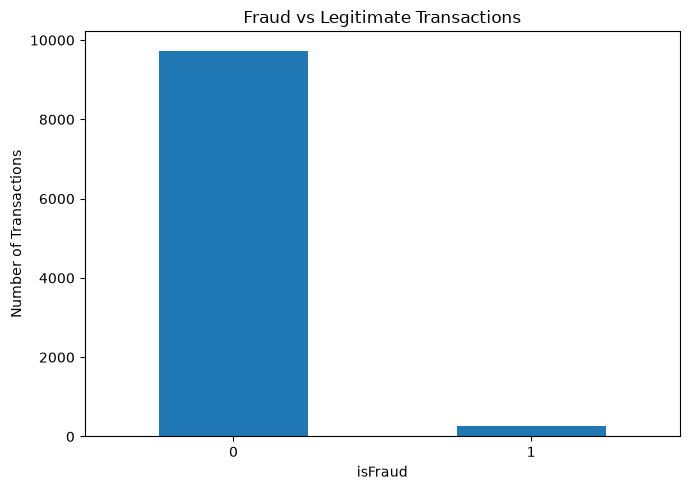

In [24]:
fraud_counts.sort_index().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
missing_transaction = (
    transaction_sample.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_transaction.head(30)

D7       97.77
D13      97.20
dist2    96.22
D12      95.94
D14      95.50
D6       95.09
D8       89.00
D9       89.00
V152     86.18
V142     86.18
V143     86.18
V144     86.18
V145     86.18
V146     86.18
V147     86.18
V149     86.18
V141     86.18
V165     86.18
V151     86.18
V154     86.18
V138     86.18
V139     86.18
V157     86.18
V140     86.18
V150     86.18
V153     86.18
V155     86.18
V162     86.18
V161     86.18
V166     86.18
dtype: float64

In [26]:
missing_identity = (
    identity_sample.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_identity.head(30)

id_24         96.68
id_21         96.44
id_25         96.41
id_08         96.41
id_07         96.41
id_22         96.40
id_23         96.40
id_27         96.40
id_26         96.40
id_18         70.83
id_04         54.21
id_03         54.21
id_10         46.06
id_09         46.06
id_33         36.75
id_34         31.99
id_30         31.65
id_32         31.64
id_14         30.08
id_13         22.77
DeviceInfo    13.85
id_16          8.13
id_06          5.21
id_05          5.21
id_20          3.39
id_17          3.36
id_19          3.36
id_31          2.66
id_02          2.50
id_36          2.50
dtype: float64

In [27]:
categorical_candidates = [
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain",
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9"
]

existing_categorical = [
    col for col in categorical_candidates
    if col in transaction_sample.columns
]

unique_counts = (
    transaction_sample[existing_categorical]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

unique_counts

card1            2057
card2             419
addr1              61
P_emaildomain      51
card5              46
R_emaildomain      40
card3              27
ProductCD           5
card4               5
M4                  4
addr2               3
card6               3
M6                  3
M2                  3
M3                  3
M5                  3
M8                  3
M7                  3
M9                  3
M1                  2
dtype: int64

In [28]:
transaction_sample["TransactionAmt"].describe()

count    10000.000000
mean       131.532165
std        215.136534
min          1.896000
25%         44.000000
50%         74.950000
75%        131.058000
max       3247.910000
Name: TransactionAmt, dtype: float64

In [29]:
transaction_sample["amount_log"] = np.log1p(
    transaction_sample["TransactionAmt"]
)

transaction_sample["amount_log"].describe()

count    10000.000000
mean         4.384452
std          0.924432
min          1.063330
25%          3.806662
50%          4.330075
75%          4.883241
max          8.086075
Name: amount_log, dtype: float64

In [30]:
SECONDS_PER_DAY = 86400

transaction_sample["transaction_day"] = (
    transaction_sample["TransactionDT"] // SECONDS_PER_DAY
)

transaction_sample["transaction_hour"] = (
    (transaction_sample["TransactionDT"] % SECONDS_PER_DAY)
    // 3600
)

transaction_sample[
    [
        "TransactionDT",
        "transaction_day",
        "transaction_hour"
    ]
].head()

,TransactionDT,transaction_day,transaction_hour
0,86400,1,0
1,86401,1,0
2,86469,1,0
3,86499,1,0
4,86506,1,0


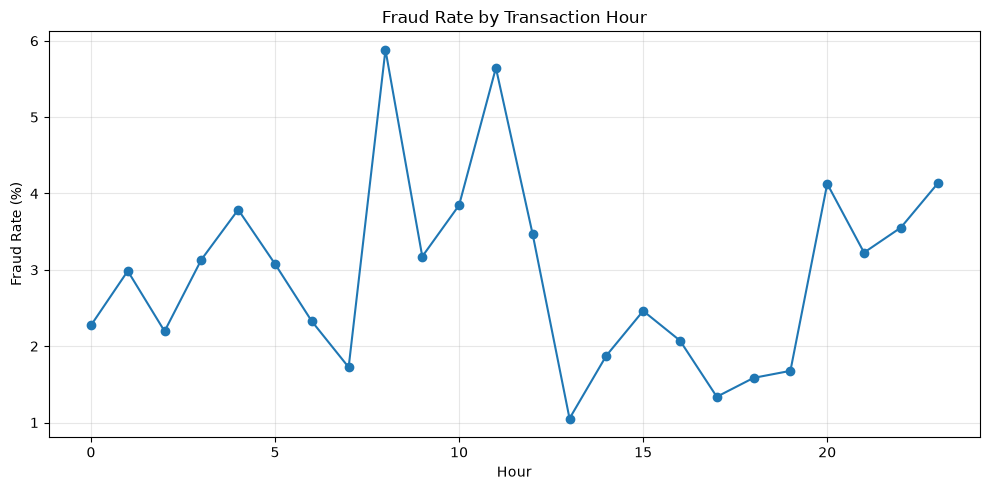

In [31]:
fraud_by_hour = (
    transaction_sample
    .groupby("transaction_hour")["isFraud"]
    .mean()
    .mul(100)
)

fraud_by_hour.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
transaction_sample["amount_bin"] = pd.qcut(
    transaction_sample["TransactionAmt"],
    q=10,
    duplicates="drop"
)

fraud_by_amount = (
    transaction_sample
    .groupby("amount_bin", observed=True)["isFraud"]
    .mean()
    .mul(100)
)

fraud_by_amount

amount_bin
(1.895, 25.95]        2.859867
(25.95, 39.0]         1.672862
(39.0, 50.0]          2.054341
(50.0, 57.95]         2.362205
(57.95, 74.95]        1.746217
(74.95, 100.0]        4.008293
(100.0, 115.0]        1.436266
(115.0, 160.5]        3.009027
(160.5, 269.955]      3.206413
(269.955, 3247.91]    3.100000
Name: isFraud, dtype: float64

In [33]:
identity_ids = set(
    identity_sample["TransactionID"]
)

transaction_sample["has_identity_sample"] = (
    transaction_sample["TransactionID"]
    .isin(identity_ids)
)

print(
    "Identity coverage in this sample:",
    transaction_sample["has_identity_sample"].mean() * 100,
    "%"
)

Identity coverage in this sample: 21.6 %


In [34]:
print(
    "Duplicate TransactionIDs:",
    transaction_sample["TransactionID"].duplicated().sum()
)

Duplicate TransactionIDs: 0


In [35]:
identity_availability = (
    transaction_sample
    .groupby("has_identity_sample")["isFraud"]
    .agg(["count", "mean"])
)

identity_availability["fraud_rate_percent"] = (
    identity_availability["mean"] * 100
)

identity_availability

,count,mean,fraud_rate_percent
has_identity_sample,,,
False,7840,0.017857,1.785714
True,2160,0.057870,5.787037


In [36]:
print("========== PAYGUARD AI EDA SUMMARY ==========")

print(
    "\nTransaction sample:",
    transaction_sample.shape
)

print(
    "Identity sample:",
    identity_sample.shape
)

print(
    "Transaction columns:",
    len(transaction_sample.columns)
)

print(
    "Identity columns:",
    len(identity_sample.columns)
)

print(
    "Fraud rate:",
    transaction_sample["isFraud"].mean() * 100,
    "%"
)

print(
    "Duplicate TransactionIDs:",
    transaction_sample["TransactionID"].duplicated().sum()
)

========== PAYGUARD AI EDA SUMMARY ==========

Transaction sample: (10000, 399)
Identity sample: (10000, 41)
Transaction columns: 399
Identity columns: 41
Fraud rate: 2.65 %
Duplicate TransactionIDs: 0
